In [ ]:
# ============================================================
# 머신러닝 실습 퀴즈 
# 주제: 제조 공정 품질 이상 분류
# ============================================================

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline   # 전처리, Feature 선택, 모델 학습을 하나의 흐름으로 묶어줌
from sklearn.impute import SimpleImputer   # 결측치를 (중앙값, 최빈값 등)으로 채워줌

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# 평가지표
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

# 분석 모델
from sklearn.linear_model import LogisticRegression  # 로지스틱 회귀 모델
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # 랜덤포레스트, 그래디언트부스팅 앙상블 모델
from sklearn.inspection import permutation_importance  # 학습된 모델에서 feature 중요도를 해석할 때 사용

np.random.seed(42)  # 난수 시드 고정하여 실행할 때마다 같은 결과 나오도록 함

In [ ]:
# ============================================================
# 1. 가상 제조 데이터 생성
# ============================================================

In [3]:


n_samples = 1500  # 샘플 수를 1500개로 설정

# 평균 75, 표준편차 10인 분포를 따르는 정규분포의 데이터로 생성
temperature = np.random.normal(75, 10, n_samples)       # 공정 온도
pressure = np.random.normal(30, 5, n_samples)           # 압력
vibration = np.random.normal(4.5, 1.2, n_samples)       # 진동
humidity = np.random.normal(45, 12, n_samples)          # 습도
torque = np.random.normal(220, 35, n_samples)           # 모터의 출력 토크 (힘) 
speed = np.random.normal(1500, 250, n_samples)          # 모터 회전속도
operator_experience = np.random.normal(5, 2, n_samples) # 작업자 숙련도(년수)

# 장비 타입을 A, B, C 중 하나로 생성
machine_type = np.random.choice(['A', 'B', 'C'], n_samples, p=[0.4, 0.35, 0.25])
# 근무조를 Day, Night 중 하나로 생성
shift = np.random.choice(['day', 'night'], n_samples, p=[0.6, 0.4])
# 재료 등급을 low, medium, hight 중 하나로 생성
material_grade = np.random.choice(['low', 'medium', 'high'], n_samples, p=[0.2, 0.5, 0.3])

# 품질 불량 기준 정의
risk_score = (
    0.04 * (temperature - 75) +          # 온도가 기준보다 높을수록 위험 증가
    0.07 * (pressure - 30) +             # 압력이 기준보다 높을수록 위험 증가
    0.35 * (vibration - 4.5) +           # 진동은 비교적 큰 영향을 주도록 가중치를 크게 설정
    0.015 * (humidity - 45) +            # 습도도 일부 영향
    0.01 * (torque - 220) -              # 토크 증가 영향
    0.003 * (speed - 1500) -             # 속도가 증가하면 약간 안정화되도록 음수 가중치
    0.15 * (operator_experience - 5)     # 숙련도가 높을수록 불량 감소
)

# 범주형 영향도
# 특정 장비 타입, 야간 근무, 저등급 재료일때 위험 점수를 추가하기 위한 기준
risk_score += np.where(machine_type == 'C', 0.45, 0.0)
risk_score += np.where(shift == 'night', 0.35, 0.0)
risk_score += np.where(material_grade == 'low', 0.50, 0.0)
risk_score += np.where(material_grade == 'high', -0.20, 0.0)

# 비선형/상호작용 영향 가중치 (단일 변수 뿐만 아니라, 다변량의 상호작용도 위험에 영향을 주도록 설정)
risk_score += 0.0008 * (temperature * vibration)
risk_score += 0.0005 * (pressure * humidity)

# 온도가 매우 높고 진동도 높은 경우 추가적인 위험을 크게 부여하기 위한 기준
risk_score += np.where((temperature > 90) & (vibration > 6), 1.0, 0.0)


# sigmoid로 확률화 (risk score를 0~1 사이의 확률로 변환
prob = 1 / (1 + np.exp(-risk_score))

# 확률에 따라 0 또는 1의 실제 레이블을 생성 (1은 불량, 0은 정상)
target = np.random.binomial(1, prob)

# 생성한 모든 변수를 데이터프레임으로 합침
df = pd.DataFrame({
    'temperature': temperature,
    'pressure': pressure,
    'vibration': vibration,
    'humidity': humidity,
    'torque': torque,
    'speed': speed,
    'operator_experience': operator_experience,
    'machine_type': machine_type,
    'shift': shift,
    'material_grade': material_grade,
    'defect': target
})

In [4]:
df

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,machine_type,shift,material_grade,defect
0,74.475523,39.624192,2.914520,52.855704,159.439658,1758.556669,8.275510,A,night,medium,1
1,80.799722,31.430079,5.683817,40.239646,158.711199,1451.930422,5.493456,C,night,medium,1
2,81.698680,25.754883,4.644448,44.820355,242.175046,1272.395581,5.424724,A,night,high,1
3,65.560150,37.326897,4.757981,30.954459,237.072511,1112.500205,4.434775,C,day,medium,1
4,65.103407,21.021934,3.512462,46.595142,224.785643,1262.824616,4.896749,B,day,medium,0
...,...,...,...,...,...,...,...,...,...,...,...
1495,73.486371,25.836964,4.661889,19.456917,222.029114,1312.064109,5.472195,C,night,high,1
1496,46.242266,34.408482,3.786704,50.404944,253.834674,1490.345717,5.957062,A,day,medium,0
1497,73.817916,32.831354,3.125919,38.644702,272.720357,1328.829777,4.263030,B,night,low,1
1498,74.928288,27.427871,2.308919,36.030909,165.816906,1057.979689,8.141773,A,night,medium,1


In [5]:
# ============================================================
# 2. 결측치 삽입 (실습 난이도 향상)
# ============================================================

# 수치형 컬럼 일부에 5%정도 결측치를 넣어 현실 데이터처럼 모사
for col in ['temperature', 'pressure', 'vibration', 'humidity', 'torque']:
    idx = np.random.choice(df.index, size=int(0.05 * n_samples), replace=False)
    df.loc[idx, col] = np.nan

# 범주형 컬럼 일부에도 3%정도 결측치 생성
for col in ['machine_type', 'material_grade']:
    idx = np.random.choice(df.index, size=int(0.03 * n_samples), replace=False)
    df.loc[idx, col] = np.nan

In [6]:
df

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,machine_type,shift,material_grade,defect
0,74.475523,39.624192,2.914520,52.855704,159.439658,1758.556669,8.275510,A,night,medium,1
1,80.799722,31.430079,5.683817,40.239646,158.711199,1451.930422,5.493456,C,night,medium,1
2,81.698680,25.754883,4.644448,44.820355,242.175046,1272.395581,5.424724,A,night,high,1
3,65.560150,37.326897,NaN,30.954459,237.072511,1112.500205,4.434775,C,day,medium,1
4,65.103407,21.021934,3.512462,46.595142,224.785643,1262.824616,4.896749,B,day,medium,0
...,...,...,...,...,...,...,...,...,...,...,...
1495,73.486371,25.836964,4.661889,19.456917,222.029114,1312.064109,5.472195,C,night,high,1
1496,46.242266,34.408482,3.786704,50.404944,253.834674,1490.345717,5.957062,A,day,medium,0
1497,73.817916,32.831354,3.125919,38.644702,272.720357,1328.829777,4.263030,B,night,low,1
1498,74.928288,27.427871,2.308919,36.030909,165.816906,1057.979689,8.141773,NaN,night,medium,1


In [8]:
# ============================================================
# 3. Feature Engineering
# ============================================================
# 도메인 기반 feature를 생성

# 온도와 압력의 비율값 생성  (분모가 0이되는 문제를 막기 위해 1e-6을 더해줌)
df['temp_pressure_ratio'] = df['temperature'] / (df['pressure'] + 1e-6)

# 진동과 토크의 곱을 만들어서 기계적 상호작용을 반영
df['vibration_torque_interaction'] = df['vibration'] * df['torque']

# 에너지 지표로서, 토크와 속도의 비율 생성
df['energy_proxy'] = df['torque'] * df['speed']

# 온도와 습도의 차이를 만들어 환경적인 스트레스 지표 활용
df['temp_humidity_gap'] = df['temperature'] - df['humidity']

# 압력과 진동이 크고, 작업자 숙련도가 낮으면 stress index가 커짐
df['stress_index'] = (df['pressure'] * df['vibration']) / (df['operator_experience'] + 1)

In [9]:
# ============================================================
# 4. 데이터 확인
# ============================================================

# 구분선 출력
print("=" * 80)

# 상위 5개 행을 출력해서 데이터 형태 확인
print("데이터 상위 5행")
print(df.head())
print("=" * 80)
print("\n데이터 정보")
print(df.info())

# 타겟 클래스 비율 확인
print("\n클래스 분포")
print(df['defect'].value_counts(normalize=True))


데이터 상위 5행
   temperature   pressure  vibration   humidity      torque        speed  \
0    74.475523  39.624192   2.914520  52.855704  159.439658  1758.556669   
1    80.799722  31.430079   5.683817  40.239646  158.711199  1451.930422   
2    81.698680  25.754883   4.644448  44.820355  242.175046  1272.395581   
3    65.560150  37.326897        NaN  30.954459  237.072511  1112.500205   
4    65.103407  21.021934   3.512462  46.595142  224.785643  1262.824616   

   operator_experience machine_type  shift material_grade  defect  \
0             8.275510            A  night         medium       1   
1             5.493456            C  night         medium       1   
2             5.424724            A  night           high       1   
3             4.434775            C    day         medium       1   
4             4.896749            B    day         medium       0   

   temp_pressure_ratio  vibration_torque_interaction   energy_proxy  \
0             1.879547                    464.6

In [10]:
# ============================================================
# 5. 입력/타깃 분리
# ============================================================

# 입력 변수 x는 defect 컬럼 제외한 나머지 컬럼
X = df.drop(columns=['defect'])

# 타겟 y는 defect 컬럼
y = df['defect']

# 수치형 컬럼명을 별도로 리스트로 관리
numeric_features = [
    'temperature', 'pressure', 'vibration', 'humidity', 'torque',
    'speed', 'operator_experience', 'temp_pressure_ratio',
    'vibration_torque_interaction', 'energy_proxy',
    'temp_humidity_gap', 'stress_index'
]

# 범주형 컬럼도 별도로 리스트로 관리
categorical_features = ['machine_type', 'shift', 'material_grade']

In [11]:
# ============================================================
# 6. 학습/테스트 분리
# ============================================================

# 학습데이터 80%, 테스트데이터 20%로 나눔
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,                   # 클래스 비율이 80%/20% 동일한 비율로 적용
    random_state=42
)

In [12]:
# ============================================================
# 7. 전처리 파이프라인
# ============================================================

# 수치형 데이터 처리 파이프라인
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),        # 수치형 결측치는 중앙값으로 치환
    ('scaler', StandardScaler())                          # 수치형 데이터를 평균 0, 표준편차 1로 스케일링
])


# 범주형 데이터 처리 파이프라인
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),     # 범주형 결측치는 최빈값으로 치환
    ('onehot', OneHotEncoder(handle_unknown='ignore'))        # 범주형은 원-핫 인코딩 처리  
])

# ColumnTransformer로 수치형/범주형에 서로 다른 전처리를 적용
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])    

In [14]:
# ============================================================
# 8. 모델 파이프라인 정의
# ============================================================

# 여러 모델을 딕셔너리 형태로 정의
models = {
    # LogisticRegression은 선형 기반 분류 모델.
    'LogisticRegression': LogisticRegression(max_iter=2000),

    # RandomForest는 여러 트리를 앙상블한 모델
    'RandomForest': RandomForestClassifier(
        n_estimators=250,        # 트리 개수
        max_depth=8,             # 트리 최대 깊이
        min_samples_split=10,    # 노드 분할 최소 샘플 수
        random_state=42
    ),

    # GradientBoosting은 순차적으로 오차를 줄여가는 부스팅 모델
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=150,        # 약한 학습기 개수
        learning_rate=0.05,      # 학습률
        max_depth=3,             # 각 트리의 최대 깊이
        random_state=42
    )
}

# 각 모델별 전체 파이프라인을 저장할 딕셔너리 생성
pipelines = {}

# 각 모델마다 전처리 + feature 선택 + 분류기를 하나의 파이프라인으로 생성
for model_name, model in models.items():
    pipelines[model_name] = Pipeline(steps=[
        ('preprocessor', preprocessor),                                         # 먼저 전처리 수행
        ('feature_select', SelectKBest(score_func=mutual_info_classif, k=15)),  # 상위 15개 feature 선택
        ('classifier', model)                                                   # 마지막 분류 모델 적용
    ])
   
        
        

In [15]:
# ============================================================
# 9. 교차검증 성능 비교
# ============================================================

# StratifiedKFold를 사용해서 클래스 비율을 유지하면서 5등분 교차 검증 진행
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 각 모델의 교차검증 결과를 저장할 리스트
cv_results = []

# 모델 별 성능 비교
for model_name, pipe in pipelines.items():
    # cross_val_score로 학습데이터에서 F1-Score 기준 교차검증 수행
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')

    # 결과를 cv_results 리스트에 딕셔너리로 저장
    cv_results.append({
        'model': model_name,
        'cv_f1_mean': scores.mean(),
        'cv_f1_std': scores.std()
    })

# 교차검증 결과를 데이터프레임으로 만들고, 평균 F1 기준 내림차순 정렬
cv_df = pd.DataFrame(cv_results).sort_values(by='cv_f1_mean', ascending=False)

# 결과 출력
print("\n" + "=" * 80)
print("교차검증 결과(F1 기준)")
print(cv_df)
print("=" * 80)

# 가장 성능이 좋은 모델 이름 선택
best_model_name = cv_df.iloc[0]['model']

# 선택된 해당 모델의 파이프라인을 최종 모델로 선정
best_pipeline = pipelines[best_model_name]

# 선택된 최종 모델 출력
print(f"\n선정된 최종 모델: {best_model_name}")


교차검증 결과(F1 기준)
                model  cv_f1_mean  cv_f1_std
0  LogisticRegression    0.840417   0.009327
1        RandomForest    0.837448   0.011244
2    GradientBoosting    0.832630   0.020861

선정된 최종 모델: LogisticRegression


In [16]:
# ============================================================
# 10. 최종 모델 학습
# ============================================================

# 선택된 최종 파이프라인을 전체 학습 데이터(80%)에 대해 학습시킴 
best_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('feature_select', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [17]:
# ============================================================
# 11. 테스트 데이터 예측
# ============================================================

# 테스트데이터 (20%) 대해 최종 클래스 예측값(0/1)을 예측
y_pred = best_pipeline.predict(X_test)

# 테스트데이터에 대해 클래스 1(불량)일 확률을 구함
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

In [18]:
# ============================================================
# 12. 모델 평가
# ============================================================

# 정확도 계산
acc = accuracy_score(y_test, y_pred)
# 정밀도 계산
prec = precision_score(y_test, y_pred)
# 재현율 계산
rec = recall_score(y_test, y_pred)
# F1-score 계산
f1 = f1_score(y_test, y_pred)
# ROC-AUC 계산
roc_auc = roc_auc_score(y_test, y_proba)

# 평가 결과 출력
print("\n테스트 성능")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

# 클래스 별 precision, recall, f1 등을 상세히 출력
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix 결과 출력
print("Confusion Matrix")
print(cm)


테스트 성능
Accuracy : 0.7667
Precision: 0.7935
Recall   : 0.9116
F1-score : 0.8485
ROC-AUC  : 0.7970

Classification Report
              precision    recall  f1-score   support

           0       0.64      0.40      0.49        85
           1       0.79      0.91      0.85       215

    accuracy                           0.77       300
   macro avg       0.72      0.66      0.67       300
weighted avg       0.75      0.77      0.75       300

Confusion Matrix
[[ 34  51]
 [ 19 196]]


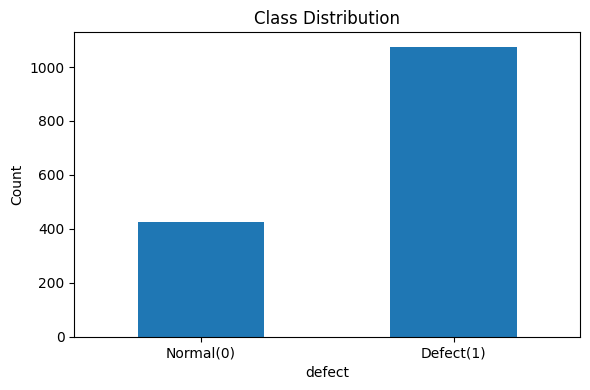

In [19]:
# ============================================================
# 13. 시각화 1 - 클래스 분포
# ============================================================
plt.figure(figsize=(6, 4))
df['defect'].value_counts().sort_index().plot(kind='bar')  # 클래스 : defect 0 or 1
# x축 눈금 라벨 지정
plt.xticks([0, 1], ['Normal(0)', 'Defect(1)'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()     # 레이아웃 자동 조절
plt.show()

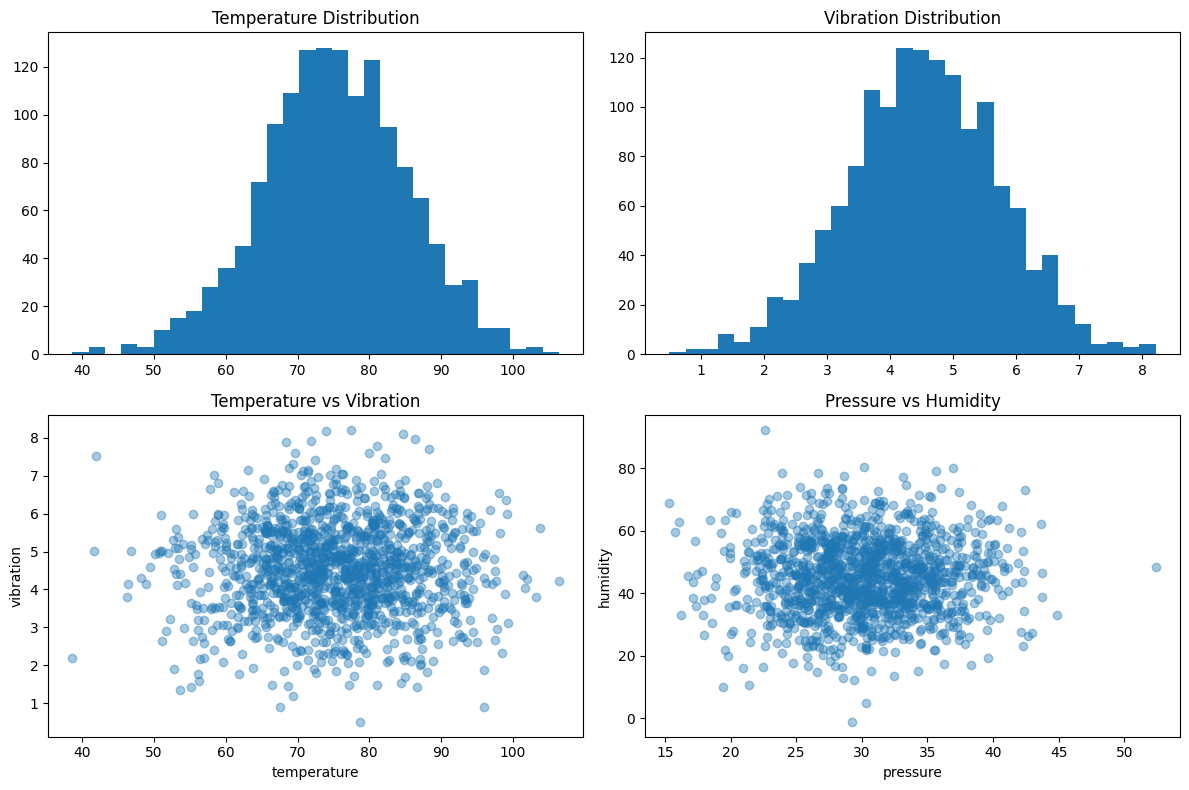

In [20]:
# ============================================================
# 14. 시각화 2 - 주요 변수 분포
# ============================================================
# 2행 2열 subplot 생성
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# temperature 히스토그램
axes[0, 0].hist(df['temperature'].dropna(), bins=30)
axes[0, 0].set_title('Temperature Distribution')

# vibration 히스토그램
axes[0, 1].hist(df['vibration'].dropna(), bins=30)
axes[0, 1].set_title('Vibration Distribution')

# temperature와 vibration 산점도
axes[1, 0].scatter(df['temperature'], df['vibration'], alpha=0.4)
axes[1, 0].set_title('Temperature vs Vibration')
axes[1, 0].set_xlabel('temperature')
axes[1, 0].set_ylabel('vibration')

# pressure와 humidity 산점도
axes[1, 1].scatter(df['pressure'], df['humidity'], alpha=0.4)
axes[1, 1].set_title('Pressure vs Humidity')
axes[1, 1].set_xlabel('pressure')
axes[1, 1].set_ylabel('humidity')

plt.tight_layout()
plt.show()

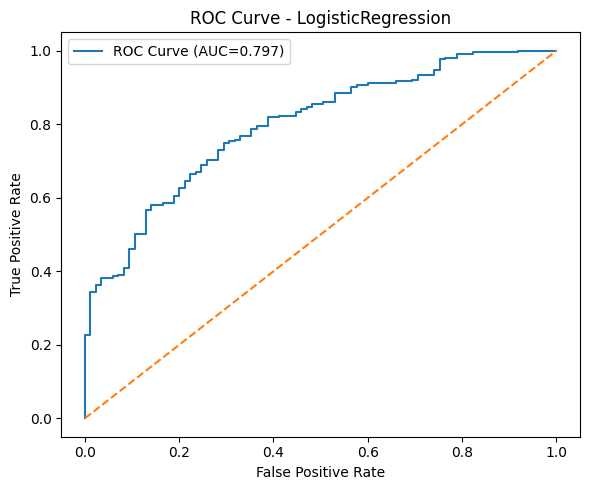

In [21]:
# ============================================================
# 15. 시각화 3 - ROC Curve
# ============================================================
# ROC curve 계산
fpr, tpr, _ = roc_curve(y_test, y_proba)
# figure 생성
plt.figure(figsize=(6, 5))
# ROC curve 그리기
plt.plot(fpr, tpr, label=f'ROC Curve (AUC={roc_auc:.3f})')
# 랜덤 분류 기준선
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')

plt.legend()
plt.tight_layout()
plt.show()

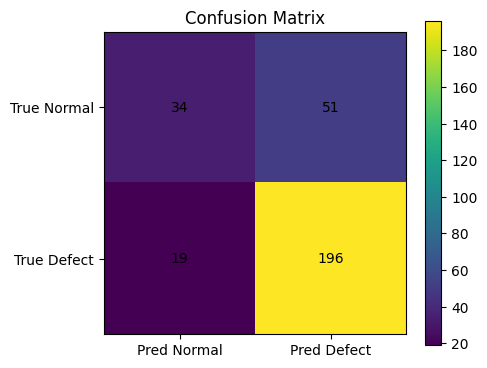

In [22]:
# ============================================================
# 17. 시각화 5 - Confusion Matrix
# ============================================================
plt.figure(figsize=(5, 4))
# Confusion Matrix을 이미지처럼 출력
plt.imshow(cm, interpolation='nearest')

plt.title('Confusion Matrix')
# 컬러바 추가
plt.colorbar()
# x축 눈금 라벨
plt.xticks([0, 1], ['Pred Normal', 'Pred Defect'])
# y축 눈금 라벨
plt.yticks([0, 1], ['True Normal', 'True Defect'])

# 셀 안에 실제 숫자 값을 텍스트로 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()


상위 중요 feature
              feature  importance_mean
3               speed         0.041498
0         temperature         0.030796
1            pressure         0.016439
7   temp_humidity_gap         0.014063
9      machine_type_B         0.011131
6        energy_proxy         0.011061
12        shift_night         0.006406
11          shift_day         0.006406
8        stress_index         0.002317
10     machine_type_C         0.001815


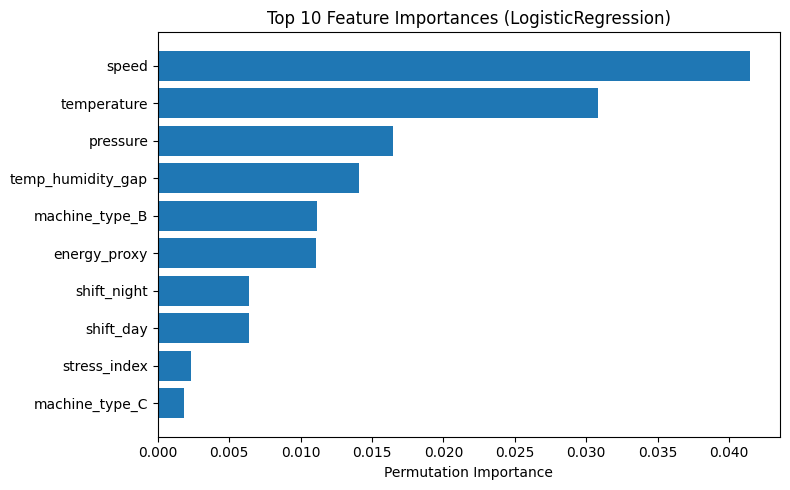

In [23]:
# ============================================================
# 18. 모델 해석 - Feature Importance
# ============================================================

# 전처리를 완료한 후, 파이프라인 내부에서 전처리기, feature selector, classifier를 꺼낸다
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
feature_selector = best_pipeline.named_steps['feature_select']
classifier = best_pipeline.named_steps['classifier']

# 테스트 데이터 전처리만 먼저 수행
X_test_transformed = preprocessor_fitted.transform(X_test)

# onthot 포함 전체 feature name --> 범주형 원-핫 인코더를 꺼냄
cat_ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']

# 원-핫 인코딩 후 생성된 범주형 feature 이름을 가져온다.
cat_feature_names = cat_ohe.get_feature_names_out(categorical_features)

# 전체 feature name = 수치형 feature + onehot 인코딩된 범주형 feature가 됨
all_feature_names = np.array(numeric_features + list(cat_feature_names))

# SelectKBest가 선택한 feature 위치를 True/False 마스크로 얻는다.
selected_mask = feature_selector.get_support()

# 선택된 feature 이름만 추출한다.
selected_feature_names = all_feature_names[selected_mask]

# 전처리된 테스트 데이터를 feature selector로 다시 변환한다.
X_test_selected = feature_selector.transform(X_test_transformed)

# feature importance 계산 --> feature가 영향도가 있으때, F1-Score가 얼마나 떨어지는지를 보고 중요도를 측정
perm_result = permutation_importance(
    classifier, X_test_selected, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

# 중요도 결과를 데이터프레임으로 정리하고 내림차순 정렬
importance_df = pd.DataFrame({
    'feature': selected_feature_names,
    'importance_mean': perm_result.importances_mean
}).sort_values(by='importance_mean', ascending=False)

# 상위 10개 feature 출력
print("\n상위 중요 feature")
print(importance_df.head(10))

# 중요도 시각화
plt.figure(figsize=(8, 5))

# 상위 10개를 선택
top_n = 10

# 가로막대그래프는 아래에서 위로 보이므로 뒤집어서 정렬
plot_df = importance_df.head(top_n).iloc[::-1]
# 가로 막대그래프
plt.barh(plot_df['feature'], plot_df['importance_mean'])
plt.title(f'Top {top_n} Feature Importances ({best_model_name})')
plt.xlabel('Permutation Importance')
plt.tight_layout()
plt.show()


신규 데이터 예측 결과
   temperature  pressure  vibration machine_type  shift material_grade  \
0           82        31        4.8            A    day         medium   
1           95        40        7.2            C  night            low   
2           68        25        3.5            B    day           high   
3           88        36        6.5            C  night         medium   
4           77        29        4.2            A    day         medium   

   predicted_class predicted_label  defect_probability  
0                1          Defect            0.823955  
1                1          Defect            0.999571  
2                0          Normal            0.212634  
3                1          Defect            0.992249  
4                1          Defect            0.622787  


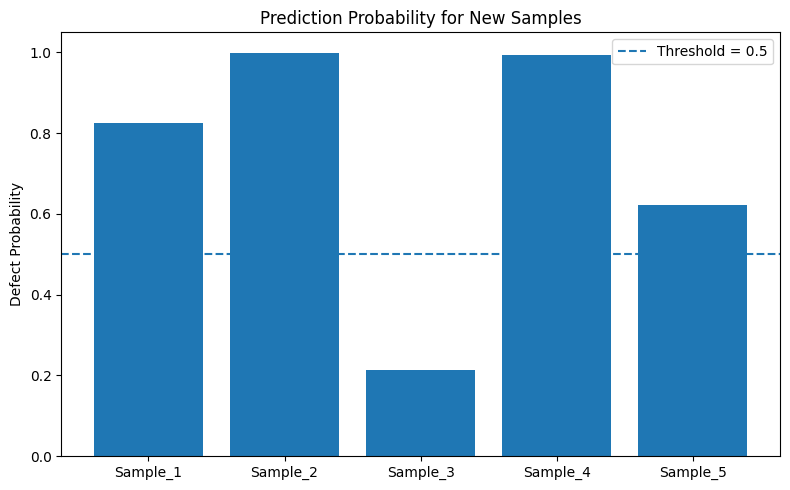


[최종 해석]
- 최종 선택 모델: LogisticRegression
- 테스트 F1-score: 0.8485
- 테스트 ROC-AUC : 0.7970
- defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있음
- 중요 feature를 통해 어떤 공정 인자가 품질 이상에 큰 영향을 주는지 파악할 수 있음


In [26]:
# ============================================================
# 19. 신규 데이터 예측
# ============================================================

# 새로운 샘플 5개를 직접 만듬
new_samples = pd.DataFrame({
    'temperature': [82, 95, 68, 88, 77],
    'pressure': [31, 40, 25, 36, 29],
    'vibration': [4.8, 7.2, 3.5, 6.5, 4.2],
    'humidity': [48, 62, 38, 50, 44],
    'torque': [230, 280, 190, 260, 215],
    'speed': [1480, 1320, 1580, 1400, 1510],
    'operator_experience': [5, 2, 8, 3, 6],
    'machine_type': ['A', 'C', 'B', 'C', 'A'],
    'shift': ['day', 'night', 'day', 'night', 'day'],
    'material_grade': ['medium', 'low', 'high', 'medium', 'medium']
})

# 학습 때 만든 파생변수를 신규 데이터에도 동일하게 만듬
new_samples['temp_pressure_ratio'] = new_samples['temperature'] / (new_samples['pressure'] + 1e-6)
new_samples['vibration_torque_interaction'] = new_samples['vibration'] * new_samples['torque']
new_samples['energy_proxy'] = new_samples['torque'] * new_samples['speed']
new_samples['temp_humidity_gap'] = new_samples['temperature'] - new_samples['humidity']
new_samples['stress_index'] = (new_samples['pressure'] * new_samples['vibration']) / (new_samples['operator_experience'] + 1)

# 신규 데이터의 최종 클래스 예측
new_pred = best_pipeline.predict(new_samples)

# 신규 데이터의 불량 확률 예측
new_proba = best_pipeline.predict_proba(new_samples)[:, 1]

# 결과를 보기 좋게 정리하기 위해 복사본 생성
result_df = new_samples.copy()

# 예측 클래스를 컬럼으로 추가
result_df['predicted_class'] = new_pred

# 불량 확률을 컬럼으로 추가
result_df['defect_probability'] = new_proba

# 0은 Normal, 1은 Defect로 매핑한 라벨 컬럼 추가
result_df['predicted_label'] = result_df['predicted_class'].map({0: 'Normal', 1: 'Defect'})

# 결과 출력
print("\n신규 데이터 예측 결과")
print(result_df[['temperature', 'pressure', 'vibration', 'machine_type',
                 'shift', 'material_grade', 'predicted_class',
                 'predicted_label', 'defect_probability']])

# 예측 결과 시각화
# figure 생성
plt.figure(figsize=(8, 5))
plt.bar(range(len(result_df)), result_df['defect_probability'])
# 임계값 0.5 기준선 표시
plt.axhline(0.5, linestyle='--', label='Threshold = 0.5')

# x축 라벨을 Sample_1, Sample_2 ... 형식으로 표시
plt.xticks(range(len(result_df)), [f'Sample_{i+1}' for i in range(len(result_df))])
plt.ylabel('Defect Probability')
plt.title('Prediction Probability for New Samples')

plt.legend()
plt.tight_layout()
plt.show()

# 최종 결과 해석을 간단히 출력
print("\n[최종 해석]")
print(f"- 최종 선택 모델: {best_model_name}")
print(f"- 테스트 F1-score: {f1:.4f}")
print(f"- 테스트 ROC-AUC : {roc_auc:.4f}")
print("- defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있음")
print("- 중요 feature를 통해 어떤 공정 인자가 품질 이상에 큰 영향을 주는지 파악할 수 있음")